<a href="https://colab.research.google.com/github/yatli24/CHC/blob/main/2024_pred_vs_actual_TS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import calendar
import glob
import xarray as xr

In [31]:
# Loading in CHIRPS
chirps_path = '/content/drive/MyDrive/capstone_data/CHIRPS/*.nc'

chrip_files = glob.glob(chirps_path)

CHIRPS = xr.open_mfdataset(chrip_files, parallel=True)

chirps_ts = CHIRPS['precip']
print(chirps_ts)

<xarray.DataArray 'precip' (time: 528, latitude: 2000, longitude: 7200)> Size: 30GB
dask.array<open_dataset-precip, shape=(528, 2000, 7200), dtype=float32, chunksize=(26, 100, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2024-12-01
Attributes:
    units:               mm/month
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           month
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0


In [39]:
## -- South Sudan 2024 -- ##

## GFDL ##

# Read a CSV file into a DataFrame
ss_gfdl_df = pd.read_csv('/content/drive/My Drive/capstone_data/csv/south_sudan_GFDL_merged.csv')

# Filtering data for the year 2024
ss_gfdl_2024 = ss_gfdl_df[ss_gfdl_df['year'] == 2024]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
ss_gfdl_2024_monthly_avg = ss_gfdl_2024.groupby(['month'])['predicted precip'].mean().reset_index()

# Mapping month numbers to month names
ss_gfdl_2024_monthly_avg['Month_Name'] = ss_gfdl_2024_monthly_avg['month'].apply(lambda x: calendar.month_name[x])

## CHIRPS ##
min_lat = 3.5
max_lat = 12.5
min_lon = 25
max_lon = 35

ss_chirps = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
ss_chirps_ts = ss_chirps.mean(dim = ['latitude','longitude']).to_series()
ss_chirps_df = ss_chirps.to_dataframe().reset_index()

# Year 2024
ss_chirps_df['Year'] = ss_chirps_df['time'].dt.year
ss_chirps_df['Month'] = ss_chirps_df['time'].dt.month

ss_chirps_2024 = ss_chirps_df[ss_chirps_df['Year'] == 2024]

# Grouping by month to calculate the monthly average of 'prec'
ss_chirps_2024_monthly_avg = ss_chirps_2024.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
ss_chirps_2024_monthly_avg['Month_Name'] = ss_chirps_2024_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

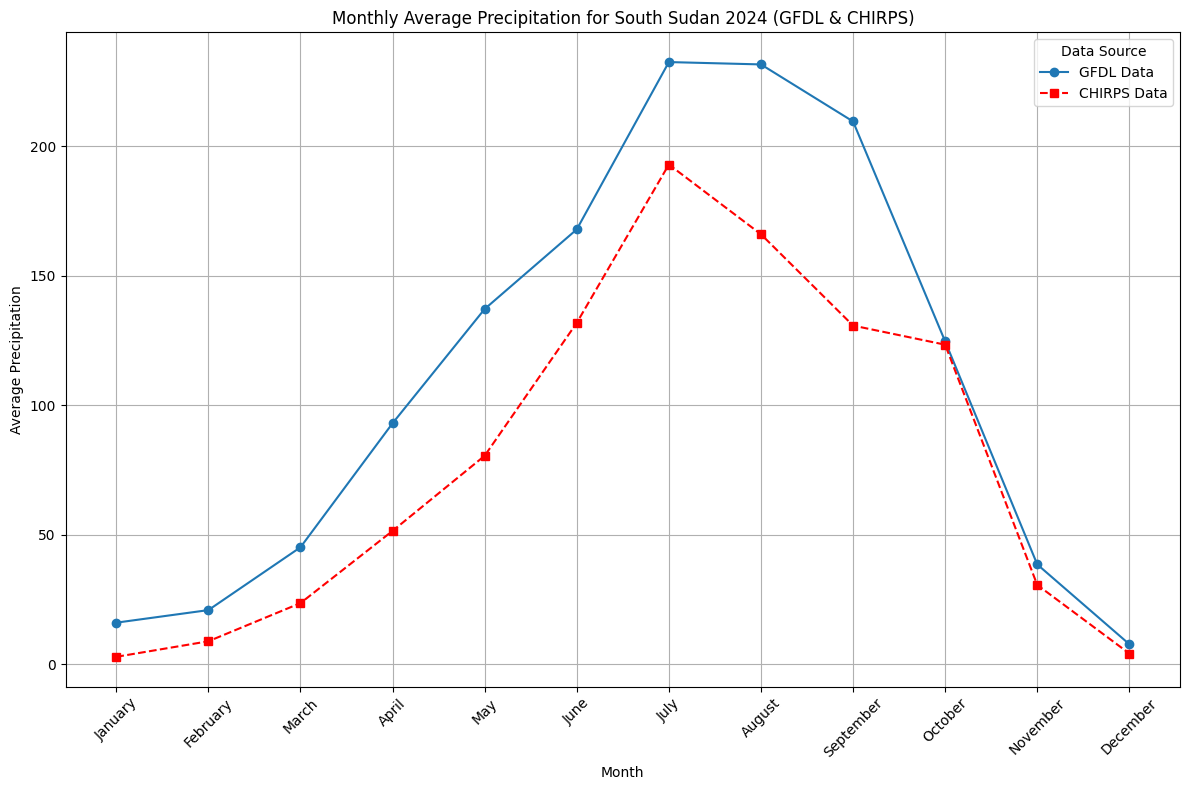

In [40]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting South Sudan GFDL data
plt.plot(ss_gfdl_2024_monthly_avg['Month_Name'], ss_gfdl_2024_monthly_avg['predicted precip']*30, marker='o', label='GFDL Data')

# Plotting South Sudan CHIRPS data
plt.plot(ss_chirps_2024_monthly_avg['Month_Name'], ss_chirps_2024_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for South Sudan 2024 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

In [37]:
## -- Eastern-East Africa 2024 -- ##

## GFDL ##

# Read a CSV file into a DataFrame
eea_gfdl_df = pd.read_csv('/content/drive/My Drive/capstone_data/csv/eastern_east_africa_GFDL_merged.csv')

# Filtering data for the year 2024
eea_gfdl_2024 = eea_gfdl_df[eea_gfdl_df['year'] == 2024]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
eea_gfdl_2024_monthly_avg = eea_gfdl_2024.groupby(['month'])['predicted precip'].mean().reset_index()

# Mapping month numbers to month names
eea_gfdl_2024_monthly_avg['Month_Name'] = eea_gfdl_2024_monthly_avg['month'].apply(lambda x: calendar.month_name[x])

## CHIRPS ##

min_lat = -3.5
max_lat = 8.5
min_lon = 38
max_lon = 50

eea_chirps = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
eea_chirps_ts = eea_chirps.mean(dim = ['latitude','longitude']).to_series()
eea_chirps_df = eea_chirps.to_dataframe().reset_index()

# Year 2024
eea_chirps_df['Year'] = eea_chirps_df['time'].dt.year
eea_chirps_df['Month'] = eea_chirps_df['time'].dt.month

eea_chirps_2024 = eea_chirps_df[eea_chirps_df['Year'] == 2024]

# Grouping by month to calculate the monthly average of 'prec'
eea_chirps_2024_monthly_avg = eea_chirps_2024.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
eea_chirps_2024_monthly_avg['Month_Name'] = eea_chirps_2024_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

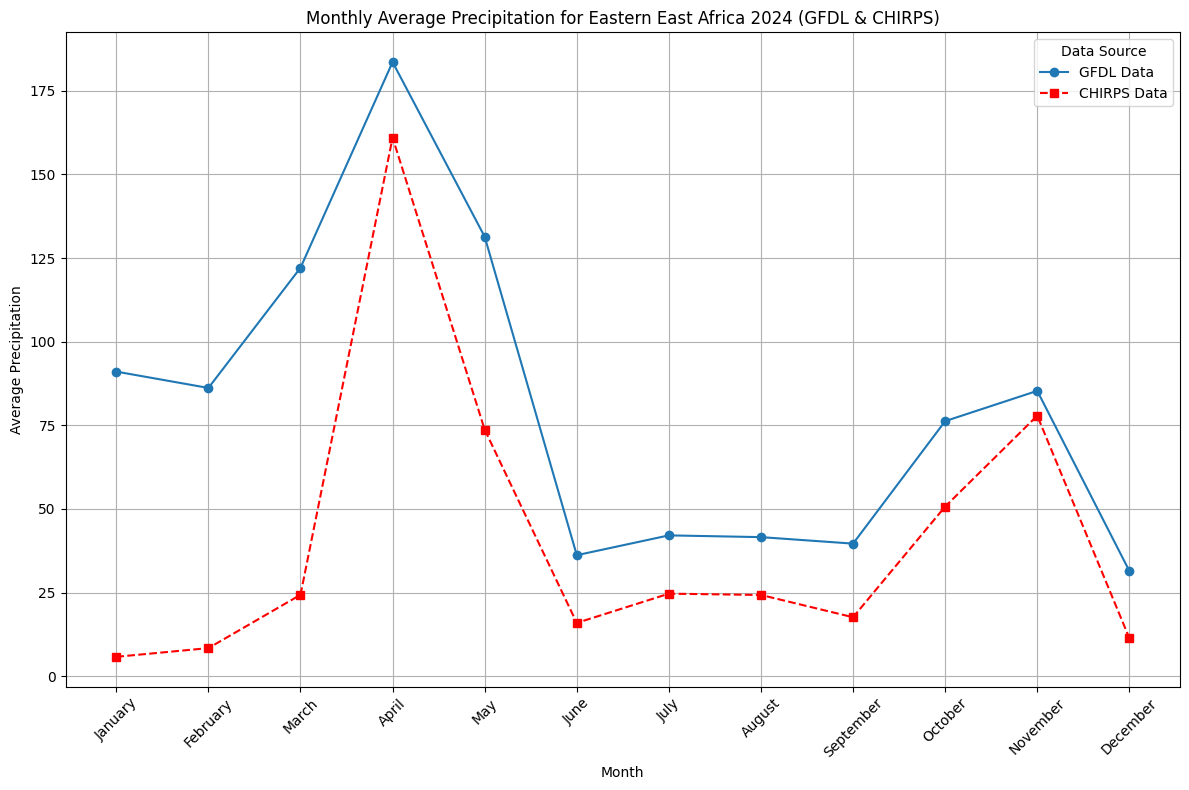

In [38]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting Eastern East Africa GFDL data
plt.plot(eea_gfdl_2024_monthly_avg['Month_Name'], eea_gfdl_2024_monthly_avg['predicted precip']*30, marker='o', label='GFDL Data')

# Plotting Eastern East Africa CHIRPS data
plt.plot(eea_chirps_2024_monthly_avg['Month_Name'], eea_chirps_2024_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for Eastern East Africa 2024 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

In [41]:
## -- Eastern Ukraine 2024 -- ##


## GFDL ##

# Read a CSV file into a DataFrame
euk_gfdl_df = pd.read_csv('/content/drive/My Drive/capstone_data/csv/eastern_ukraine_GFDL_merged.csv')

# Filtering data for the year 2024
euk_gfdl_2024 = euk_gfdl_df[euk_gfdl_df['year'] == 2024]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
euk_gfdl_2024_monthly_avg = euk_gfdl_2024.groupby(['month'])['predicted precip'].mean().reset_index()

# Mapping month numbers to month names
euk_gfdl_2024_monthly_avg['Month_Name'] = euk_gfdl_2024_monthly_avg['month'].apply(lambda x: calendar.month_name[x])


## CHIRPS ##

min_lat = 45
max_lat = 51
min_lon = 31
max_lon = 40

euk_chirps = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
euk_chirps_ts = euk_chirps.mean(dim = ['latitude','longitude']).to_series()
euk_chirps_df = euk_chirps.to_dataframe().reset_index()

# Year 2024
euk_chirps_df['Year'] = euk_chirps_df['time'].dt.year
euk_chirps_df['Month'] = euk_chirps_df['time'].dt.month

euk_chirps_2024 = euk_chirps_df[euk_chirps_df['Year'] == 2024]

# Grouping by month to calculate the monthly average of 'prec'
euk_chirps_2024_monthly_avg = euk_chirps_2024.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
euk_chirps_2024_monthly_avg['Month_Name'] = euk_chirps_2024_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

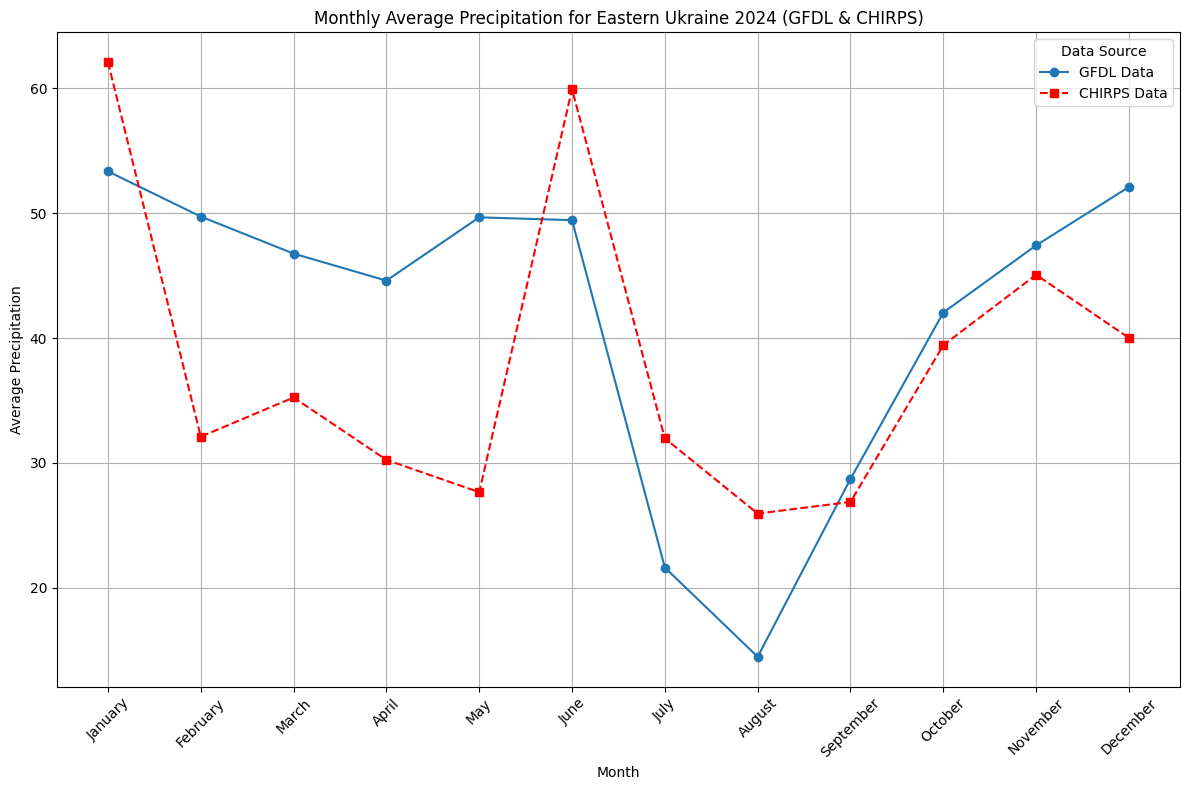

In [43]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting Eastern Ukraine GFDL data
plt.plot(euk_gfdl_2024_monthly_avg['Month_Name'], euk_gfdl_2024_monthly_avg['predicted precip']*30, marker='o', label='GFDL Data')

# Plotting Eastern East Africa CHIRPS data
plt.plot(euk_chirps_2024_monthly_avg['Month_Name'], euk_chirps_2024_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for Eastern Ukraine 2024 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

In [44]:
## -- Lake Victoria Basin -- 2024 ##


## GFDL ##

# Read a CSV file into a DataFrame
lake_victoria_gfdl_df = pd.read_csv('/content/drive/My Drive/capstone_data/csv/lake_victoria_basin_GFDL_merged.csv')

# Filtering data for the year 2024
lake_victoria_gfdl_2024 = lake_victoria_gfdl_df[lake_victoria_gfdl_df['year'] == 2024]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
lake_victoria_gfdl_2024_monthly_avg = lake_victoria_gfdl_2024.groupby(['month'])['predicted precip'].mean().reset_index()

# Mapping month numbers to month names
lake_victoria_gfdl_2024_monthly_avg['Month_Name'] = lake_victoria_gfdl_2024_monthly_avg['month'].apply(lambda x: calendar.month_name[x])

## CHIRPS ##
min_lat = -4
max_lat = 1.5
min_lon = 29
max_lon = 36

lake_victoria_chirps = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
lake_victoria_chirps_ts = lake_victoria_chirps.mean(dim = ['latitude','longitude']).to_series()
lake_victoria_chirps_df = lake_victoria_chirps.to_dataframe().reset_index()

# Year 2024
lake_victoria_chirps_df['Year'] = lake_victoria_chirps_df['time'].dt.year
lake_victoria_chirps_df['Month'] = lake_victoria_chirps_df['time'].dt.month

lake_victoria_chirps_2024 = lake_victoria_chirps_df[lake_victoria_chirps_df['Year'] == 2024]

# Grouping by month to calculate the monthly average of 'prec'
lake_victoria_chirps_2024_monthly_avg = lake_victoria_chirps_2024.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
lake_victoria_chirps_2024_monthly_avg['Month_Name'] = lake_victoria_chirps_2024_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

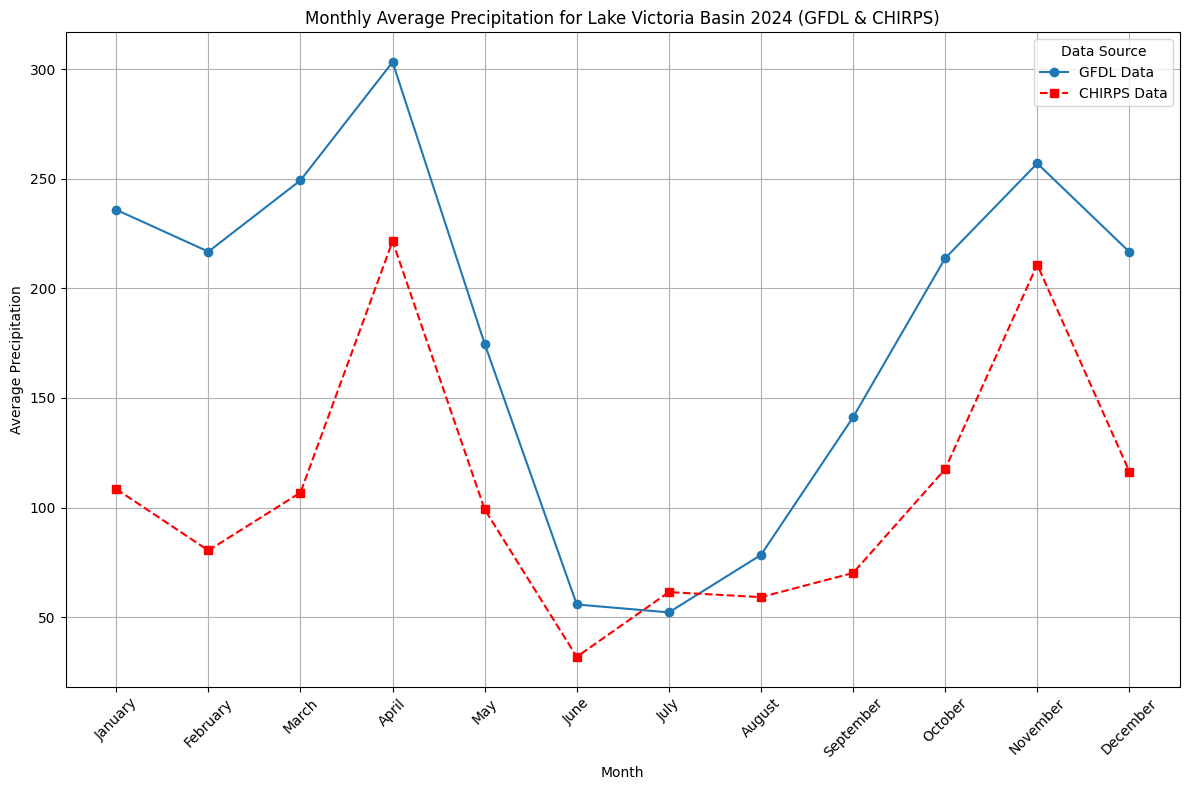

In [45]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting Lake Victoria Basin GFDL data
plt.plot(lake_victoria_gfdl_2024_monthly_avg['Month_Name'], lake_victoria_gfdl_2024_monthly_avg['predicted precip']*30, marker='o', label='GFDL Data')

# Plotting Lake Victoria Basin CHIRPS data
plt.plot(lake_victoria_chirps_2024_monthly_avg['Month_Name'], lake_victoria_chirps_2024_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for Lake Victoria Basin 2024 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

In [47]:
## -- Southern Africa 2024 -- ##


## GFDL ##

# Read a CSV file into a DataFrame
south_af_gfdl_df = pd.read_csv('/content/drive/My Drive/capstone_data/csv/southern_africa_GFDL_merged.csv')
#print(euk_gfdl_df)

# Filtering data for the year 2024
south_af_gfdl_2024 = south_af_gfdl_df[south_af_gfdl_df['year'] == 2024]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
south_af_gfdl_2024_monthly_avg = south_af_gfdl_2024.groupby(['month'])['predicted precip'].mean().reset_index()

# Mapping month numbers to month names
south_af_gfdl_2024_monthly_avg['Month_Name'] = south_af_gfdl_2024_monthly_avg['month'].apply(lambda x: calendar.month_name[x])

## CHIRPS ##
min_lat = -23
max_lat = -15
min_lon = 25
max_lon = 34

south_af_chirps = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
south_af_chirps_ts = south_af_chirps.mean(dim = ['latitude','longitude']).to_series()
south_af_chirps_df = south_af_chirps.to_dataframe().reset_index()

# Year 2024
south_af_chirps_df['Year'] = south_af_chirps_df['time'].dt.year
south_af_chirps_df['Month'] = south_af_chirps_df['time'].dt.month

south_af_chirps_2024 = south_af_chirps_df[south_af_chirps_df['Year'] == 2024]

# Grouping by month to calculate the monthly average of 'prec'
south_af_chirps_2024_monthly_avg = south_af_chirps_2024.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
south_af_chirps_2024_monthly_avg['Month_Name'] = south_af_chirps_2024_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

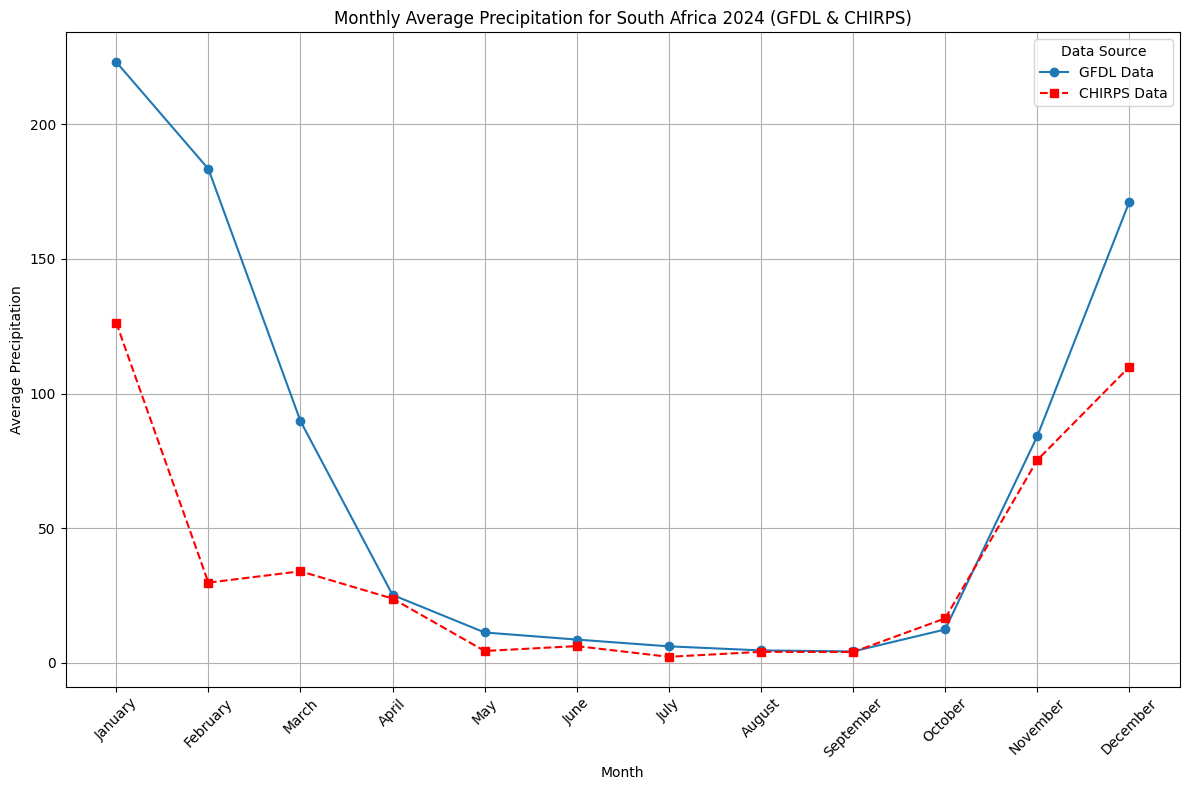

In [48]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting South Africa GFDL data
plt.plot(south_af_gfdl_2024_monthly_avg['Month_Name'], south_af_gfdl_2024_monthly_avg['predicted precip']*30, marker='o', label='GFDL Data')

# Plotting South Africa CHIRPS data
plt.plot(south_af_chirps_2024_monthly_avg['Month_Name'], south_af_chirps_2024_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for South Africa 2024 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

In [50]:
## -- Sri Lanka 2024 -- ##


## GFDL ##

# Read a CSV file into a DataFrame
sri_lanka_gfdl_df = pd.read_csv('/content/drive/My Drive/capstone_data/csv/sri_lanka_GFDL_merged.csv')

# Filtering data for the year 2024
sri_lanka_gfdl_2024 = sri_lanka_gfdl_df[sri_lanka_gfdl_df['year'] == 2024]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
sri_lanka_gfdl_2024_monthly_avg = sri_lanka_gfdl_2024.groupby(['month'])['predicted precip'].mean().reset_index()

# Mapping month numbers to month names
sri_lanka_gfdl_2024_monthly_avg['Month_Name'] = sri_lanka_gfdl_2024_monthly_avg['month'].apply(lambda x: calendar.month_name[x])

## CHIRPS ##
min_lat = 5.5
max_lat = 10
min_lon = 79.5
max_lon = 82

sri_lanka_chirps = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
sri_lanka_chirps_ts = sri_lanka_chirps.mean(dim = ['latitude','longitude']).to_series()
sri_lanka_chirps_df = sri_lanka_chirps.to_dataframe().reset_index()

# Year 2024
sri_lanka_chirps_df['Year'] = sri_lanka_chirps_df['time'].dt.year
sri_lanka_chirps_df['Month'] = sri_lanka_chirps_df['time'].dt.month

sri_lanka_chirps_2024 = sri_lanka_chirps_df[sri_lanka_chirps_df['Year'] == 2024]

# Grouping by month to calculate the monthly average of 'prec'
sri_lanka_chirps_2024_monthly_avg = sri_lanka_chirps_2024.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
sri_lanka_chirps_2024_monthly_avg['Month_Name'] = sri_lanka_chirps_2024_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

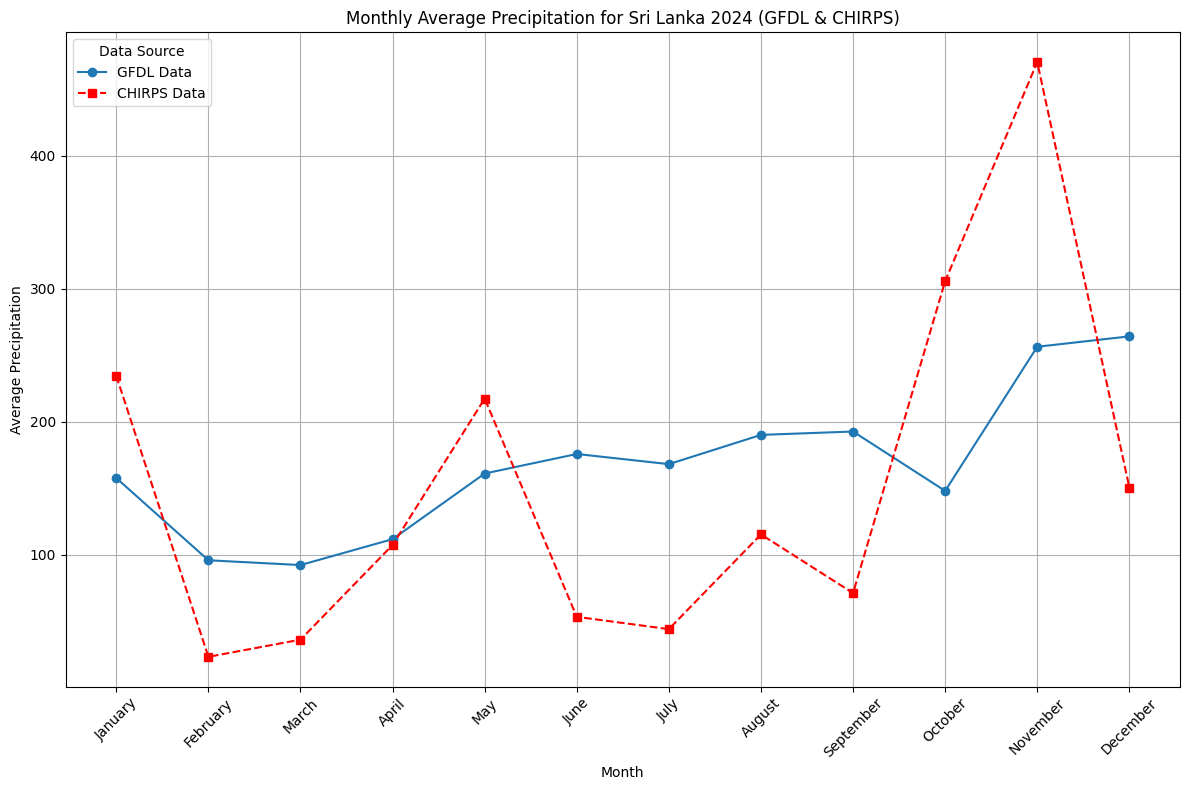

In [51]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting Sri Lanka GFDL data
plt.plot(sri_lanka_gfdl_2024_monthly_avg['Month_Name'], sri_lanka_gfdl_2024_monthly_avg['predicted precip']*30, marker='o', label='GFDL Data')

# Plotting Sri Lanka CHIRPS data
plt.plot(sri_lanka_chirps_2024_monthly_avg['Month_Name'], sri_lanka_chirps_2024_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for Sri Lanka 2024 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

In [53]:
## -- West Africa 2024 -- ##


## GFDL ##

# Read a CSV file into a DataFrame
west_africa_gfdl_df = pd.read_csv('/content/drive/My Drive/capstone_data/csv/west_africa_GFDL_merged.csv')

# Filtering data for the year 2024
west_africa_gfdl_2024 = west_africa_gfdl_df[west_africa_gfdl_df['year'] == 2024]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
west_africa_gfdl_2024_monthly_avg = west_africa_gfdl_2024.groupby(['month'])['predicted precip'].mean().reset_index()

# Mapping month numbers to month names
west_africa_gfdl_2024_monthly_avg['Month_Name'] = west_africa_gfdl_2024_monthly_avg['month'].apply(lambda x: calendar.month_name[x])

## CHIRPS ##
min_lat = 10
max_lat = 13.5
min_lon = -10
max_lon = 0

west_africa_chirps = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
west_africa_chirps_ts = west_africa_chirps.mean(dim = ['latitude','longitude']).to_series()
west_africa_chirps_df = west_africa_chirps.to_dataframe().reset_index()

# Year 2024
west_africa_chirps_df['Year'] = west_africa_chirps_df['time'].dt.year
west_africa_chirps_df['Month'] = west_africa_chirps_df['time'].dt.month

west_africa_chirps_2024 = west_africa_chirps_df[west_africa_chirps_df['Year'] == 2024]

# Grouping by month to calculate the monthly average of 'prec'
west_africa_chirps_2024_monthly_avg = west_africa_chirps_2024.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
west_africa_chirps_2024_monthly_avg['Month_Name'] = west_africa_chirps_2024_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

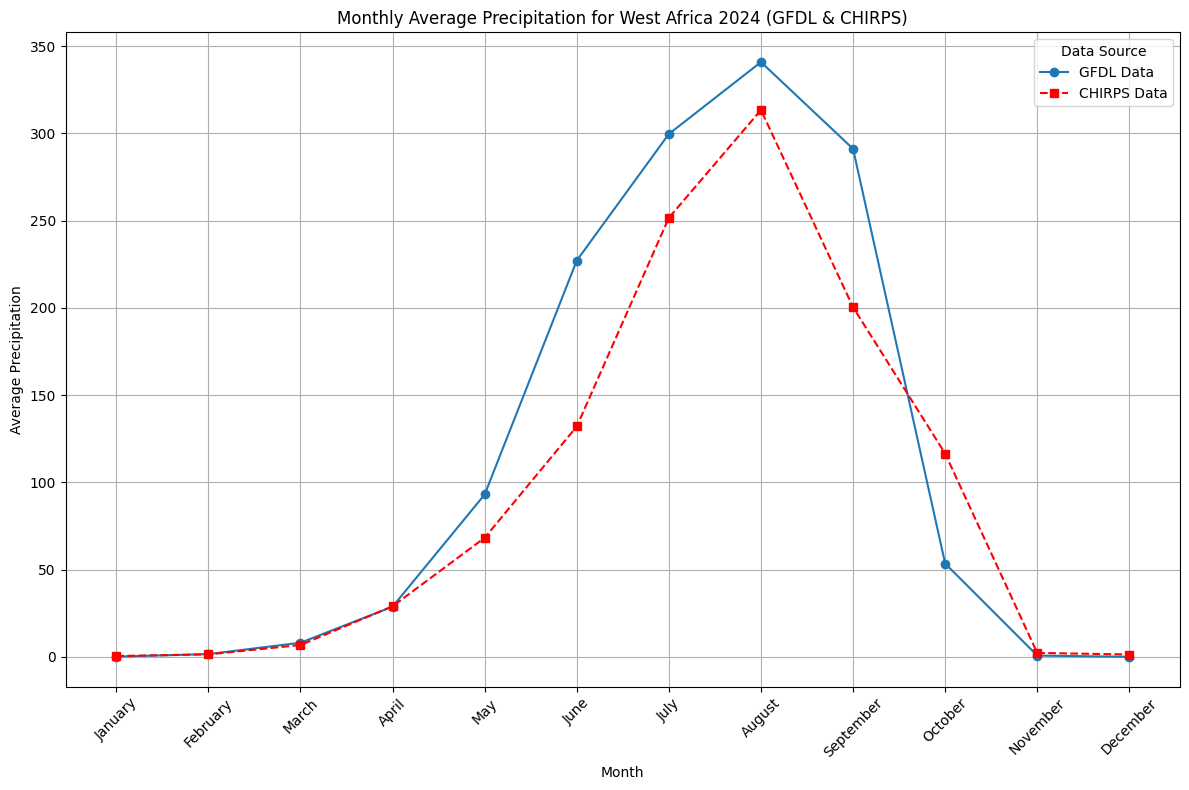

In [54]:
# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting West Africa GFDL data
plt.plot(west_africa_gfdl_2024_monthly_avg['Month_Name'], west_africa_gfdl_2024_monthly_avg['predicted precip']*30, marker='o', label='GFDL Data')

# Plotting West Africa CHIRPS data
plt.plot(west_africa_chirps_2024_monthly_avg['Month_Name'], west_africa_chirps_2024_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for West Africa 2024 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()